# Predictive task training

In [1]:
import sys
import os

project_path = "/home/sagemaker-user/gbm_hackathon"
if project_path not in sys.path:
    sys.path.append(project_path)
    print(sys.path)

['/home/sagemaker-user/.conda/envs/gbmhackathon/lib/python310.zip', '/home/sagemaker-user/.conda/envs/gbmhackathon/lib/python3.10', '/home/sagemaker-user/.conda/envs/gbmhackathon/lib/python3.10/lib-dynload', '', '/home/sagemaker-user/.conda/envs/gbmhackathon/lib/python3.10/site-packages', '/home/sagemaker-user/gbm_hackathon']


In [2]:
%load_ext autoreload
%autoreload 2
import os, sys
import pandas as pd
import numpy as np
import pickle as pkl
import torch
import seaborn as sns
import matplotlib.pyplot as plt 
import subprocess

from foundation.clinical import get_batch
from gbmhackathon.data import MosaicDataset
from gbmhackathon.s3_loader import load_s3, write_s3

In [3]:
# BUCKET_MOSAIC = "ABSTRA_DATASET_03bb30aa_16ed_4b89_913e_fe009db2aabd"
# BUCKET_PROJECT = "ABSTRA_PROJECT_STORAGE_BUCKET"

# def fetch_path(env_var_name):
#     return os.path.expandvars(f"${env_var_name}")

# S3_PATH_CLINICAL_EMB = fetch_path(BUCKET_PROJECT) + "embedding_V1/2025-03-30_14-23_clinical_emb_V1.pkl"
# S3_PATH_MODALITIES_PER_SAMPLES = fetch_path(BUCKET_MOSAIC) + "Data availibility per modality per sample.csv"
# S3_PATH_PROJECT = fetch_path(BUCKET_PROJECT)

In [4]:
# clinical_dict = load_s3(S3_PATH_CLINICAL_EMB)

In [5]:
# id2row = clinical_dict['dataset']['id2row']
# X = clinical_dict['dataset']['X']
# Y = clinical_dict['dataset']['Y']
# features = clinical_dict['dataset']['features']
# targets = clinical_dict['dataset']['targets']
# per_mod_contributions = clinical_dict['dataset']['mca_contributions']

In [6]:
# targets

In [7]:
# dict_targets = {pid:Y[id2row[pid],:] for pid in id2row.keys()}
# dict_targets

In [8]:
# freeze = False
# not freeze

In [9]:
%load_ext autoreload
%autoreload 2

from gbmhackathon.training.predictive import *
from gbmhackathon.models.mme import GBMNet
from gbmhackathon.utils.loss_functions import InfoNCELoss, RegularizedInfoNCELoss, SmoothingFunction, RankMe
from gbmhackathon.utils.module_functions import instantiate
from gbmhackathon.s3_loader import load_s3

import os
from copy import deepcopy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# To investigate gradients
from torchviz import make_dot

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim import Adam

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
torch.set_num_threads(6)
torch.get_num_threads()

6

In [11]:
device = "cpu" #"cuda" if torch.cuda.is_available() else "cpu"
torch.set_default_device(device)

In [12]:
name_emb_dict = {"hne":"embeddings_HnE_OptimusH0.pkl",
#"spatial":"2025-03-23_18-32_spatial_emb_V1.pkl",
"clinical":"2025-03-30_14-23_clinical_emb_V1.pkl",
"wes":"2025-04-05_13-40_wes_emb_V1.pkl",
"bulk":"2025-05-03_10-15_bulk_emb_V1.pkl",
"scRNA":"2025-05-04_02-35_scRNA_emb_V1.pkl"}
pkl_storage_folder = "embedding_V1"

In [13]:
dataset = PredictiveLearningDataset(name_emb_dict, pkl_storage_folder, device=device, dropout=0.35)
print(f"Dataset size: {len(dataset)}")
BATCH_SIZE = 16
dataloader = DataLoader(dataset, BATCH_SIZE, shuffle=True, collate_fn=collate_predictive, generator=torch.Generator(device=dataset.device))

Using device: cpu
By keeping 35.00% of dropout augmented samples we went from:
468 dropout samples (80.41% dropout in dataset) -- to --> 152 dropout samples (57.14% dropout in dataset)
Dataset size: 266


In [14]:
toy_batch = next(iter(dataloader))
toy_batch

(['HK_G_104a_dhne_bulk',
  'HK_G_073a_dclinical_wes_bulk',
  'HK_G_064a_dwes',
  'HK_G_102a',
  'HK_G_064a_dscRNA',
  'HK_G_113b_dclinical_wes_bulk',
  'HK_G_096b',
  'HK_G_092b_dhne_scRNA',
  'HK_G_103a',
  'HK_G_107a',
  'HK_G_056a',
  'HK_G_064a_dclinical_wes_scRNA',
  'HK_G_007a',
  'HK_G_112a',
  'HK_G_082b',
  'HK_G_081a'],
 ['hne', 'clinical', 'wes', 'bulk', 'scRNA'],
 {'hne': tensor([[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          ...,
          [-0.5082,  0.1443, -0.4044,  ...,  0.1698,  0.8256,  0.1301],
          [-0.4160,  0.3651,  0.1854,  ...,  0.1420,  0.2474, -0.3080],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]]),
  'clinical': tensor([[ 4.1322e-01,  1.1185e+00, -1.4894e-01,  3.6133e-01,  4.9483e-02,
            8.3442e-02,  1.2346e-02,  1.8161e-01,  1.4646e-01,  6.8230e-02,
  

In [15]:
raw_emb = toy_batch[2]
inpute_size_dict = {}
for mod in raw_emb.keys():
    print(mod, raw_emb[mod].size())
    inpute_size_dict[mod] = raw_emb[mod].size(1)

hne torch.Size([16, 1536])
clinical torch.Size([16, 12])
wes torch.Size([16, 1790])
bulk torch.Size([16, 3072])
scRNA torch.Size([16, 3072])


In [16]:
def make_patient_map(dataset, missing_mods_path: str = "s3://abstra-project-storage-lttemftb/1b75dc89-ad27-4a65-9e7f-877d1b4f36fc/missing_mod_per_samples.pkl"):
    missing_mods = load_s3(missing_mods_path)
    all_ids = list(missing_mods.keys())
    patient_map = {key: i for key, i in zip(all_ids, [k for k in range(1,len(all_ids)+1)])}
    for patient_id, idx in patient_map.items():
        if patient_id.endswith('b'): # pour les rechutes on met le même index que le sample original
            patient_map[patient_id] = idx - 1
    patient_number = []
    for pid in dataset.ind2patient.values():
        if 'd' in pid:
            pid = pid[:pid.index('_d')]
        patient_number.append(patient_map[pid])
    patient_map = dict(zip(dataset.ind2patient.values(), patient_number))
    idx_compatible_mapping = dict(zip(list(set(patient_map.values())), [k for k in range(len(set(patient_map.values())))]))
    for pid in patient_map.keys():
        patient_map[pid] = idx_compatible_mapping[patient_map[pid]]
    return patient_map

In [17]:
patient_map = make_patient_map(dataset)

In [18]:
def adapt_base_config(base_cfg, input_size):
    base_copy = deepcopy(base_cfg)
    base_copy["layers"] = [input_size] + base_copy["layers"]
    return base_copy

In [19]:
out = 64
norm_fn = nn.LayerNorm
base_cfg = {"layers": [1024,512,out],
        "dropout": 0.65,
        "act_fn":SmoothingFunction,
        "norm_layer":norm_fn,
        "device":device}

hne_cfg = adapt_base_config(base_cfg, inpute_size_dict["hne"])
#spatial_cfg = adapt_base_config(small_capacity_cfg, inpute_size_dict["spatial"])
clinical_cfg = adapt_base_config(base_cfg, inpute_size_dict["clinical"])
wes_cfg = adapt_base_config(base_cfg, inpute_size_dict["wes"])
bulk_cfg = adapt_base_config(base_cfg, inpute_size_dict["bulk"])
sc_cfg = adapt_base_config(base_cfg, inpute_size_dict["scRNA"])

In [20]:
mme_bulk_cfg = {"net_type": "mlp",
            "device": device,
            "net_config": bulk_cfg}

mme_hne_cfg = {"net_type": "mlp",
            "device": device,
            "net_config": hne_cfg}

mme_sc_cfg = {"net_type": "mlp",
            "device": device,
            "net_config": sc_cfg}

mme_wes_cfg = {"net_type": "mlp",
            "device": device,
            "net_config": wes_cfg}

mme_clinical_cfg = {"net_type": "mlp",
                "device": device,
                "net_config": clinical_cfg}

In [21]:
mme_cfg = {"hne_cfg":mme_hne_cfg, 
           "clinical_cfg":mme_clinical_cfg, 
           "wes_cfg":mme_wes_cfg, 
           #"spatial_cfg":mme_spatial_cfg,
           "bulk_cfg":mme_bulk_cfg,
          "sc_cfg":mme_sc_cfg}

### For PredictionHead config: first layer depends on how many modalities are used in mme. The final layer is always 5 (3 regression, 1 classification (but 2 logits for classes 1 and 0)) 

In [22]:
base_head_cfg = {"layers": [out*len(mme_cfg),1024,512,5],
        "dropout": 0.65,
        # NO ACTIVATION FOR THE LAST LAYER ! (no need for regression and already in the loss module for classification)
        "act_fn":[SmoothingFunction, SmoothingFunction, None],
        "norm_layer":norm_fn,
        "device":device}
head_cfg = {"net_type": "mlp",
            "device": device,
            "net_config": base_head_cfg}

In [23]:
gbmnet_cfg = {"head_cfg": head_cfg,
        "load_mme": False,
        "freeze_mme": False,
        "mme_path": None,
        "mme_cfg": mme_cfg}

In [24]:
gbmnet_cfg

{'head_cfg': {'net_type': 'mlp',
  'device': 'cpu',
  'net_config': {'layers': [320, 1024, 512, 5],
   'dropout': 0.65,
   'act_fn': [gbmhackathon.utils.loss_functions.SmoothingFunction,
    gbmhackathon.utils.loss_functions.SmoothingFunction,
    None],
   'norm_layer': torch.nn.modules.normalization.LayerNorm,
   'device': 'cpu'}},
 'load_mme': False,
 'freeze_mme': False,
 'mme_path': None,
 'mme_cfg': {'hne_cfg': {'net_type': 'mlp',
   'device': 'cpu',
   'net_config': {'layers': [1536, 1024, 512, 64],
    'dropout': 0.65,
    'act_fn': gbmhackathon.utils.loss_functions.SmoothingFunction,
    'norm_layer': torch.nn.modules.normalization.LayerNorm,
    'device': 'cpu'}},
  'clinical_cfg': {'net_type': 'mlp',
   'device': 'cpu',
   'net_config': {'layers': [12, 1024, 512, 64],
    'dropout': 0.65,
    'act_fn': gbmhackathon.utils.loss_functions.SmoothingFunction,
    'norm_layer': torch.nn.modules.normalization.LayerNorm,
    'device': 'cpu'}},
  'wes_cfg': {'net_type': 'mlp',
   'de

In [25]:
def predictive_training_loop(gbmnet, dataloader, EPOCHS_I=50, 
                             base_lr_I=1e-4,
                             optimizer_I=Adam,
                             scheduler_I=None,
                             scheduler_I_cfg=None,
                             EPOCHS_II=50,
                             base_lr_II=1e-4,
                             optimizer_II=Adam,
                             scheduler_II=None,
                             scheduler_II_cfg=None,
                             contrastive_loss_fn=RegularizedInfoNCELoss,
                             contrastive_loss_cfg=None,
                             reg_loss_fn=nn.MSELoss, # Classic Mean Squared Error Loss
                             clf_loss_fn=nn.BCEWithLogitsLoss, # Binary Cross Entropy with Sigmoid already applied, more stable
                             pretrained_mme=False, # If we are using a GBMNet with pretrained MME weights
                             freeze_mme=False, # If we modify the MME after Phase I or not.
                             eta_min_coef=0.01):
    # Initialize metric collectors
    pos_aligns_I, neg_aligns_I, ratio_aligns_I = [], [], []
    
    if pretrained_mme:
        EPOCHS_I_LOSSES = None
    else:
        # Optimization for Phase I
        optimizer_I = optimizer_I(gbmnet.mme.parameters(), lr=base_lr_I)
        scheduler_I_cfg["optimizer"] = optimizer_I
        if "eta_min" in scheduler_I_cfg.keys():
            if scheduler_I_cfg["eta_min"] == "dynamic":
                scheduler_I_cfg["eta_min"] = eta_min_coef * base_lr_I
        scheduler_I = instantiate(scheduler_I_cfg, scheduler_I)
    
        assert contrastive_loss_cfg is not None, "You must provide a config for the contrastive loss"

        contrastive_loss_fn = instantiate(contrastive_loss_cfg, RegularizedInfoNCELoss)

        # Phase I training loop
        EPOCHS_I_LOSSES = []
        for epoch in range(EPOCHS_I):
            epoch_loss = []
            
            for idx, batch in enumerate(dataloader):
                # Get batch
                patient_ids, modalities, X_dict, avail_mods, batch_targets, targets_names = batch
                # print(batch_targets.size())
                # Forward pass
                contrastive_outputs, _ = gbmnet(X_dict)
                # print(predictive_outputs.size())
                contrastive_loss_batch = (contrastive_outputs, patient_ids, avail_mods)
        
                # Loss computation (here me do contrastive and predictive at the same time)
                contrastive_loss = contrastive_loss_fn(contrastive_loss_batch)
            
                loss = contrastive_loss
        
                # Backward pass
                loss.backward()
                optimizer_I.step()
        
                # Learning schedule
                before_lr_I = optimizer_I.param_groups[0]["lr"]
                scheduler_I.step()
        
                # Store losses
                epoch_loss.append(loss.item())
        
            print(f"\n\nLearning Rate: {before_lr_I}")
            # For monitoring, not actually necessary
            avg_loss = np.mean(epoch_loss)
            pos_align = np.mean(contrastive_loss_fn.infonce.pos_alignments)
            neg_align = np.mean(contrastive_loss_fn.infonce.neg_alignments)
            ratio = np.abs(pos_align/(neg_align + 1e-8))
            # print("************************************************ GLOBAL ***********************************************")
            print(f"Epoch {epoch} total loss: {np.mean(epoch_loss):.4f}".upper())
            # print("*******************************************************************************************************")
        
            # print("************************************************ EMBEDDING QUALITY ***********************************************")
            # print(f"\nEpoch {epoch} Embedding quality (Alignement): {pos_align:.4f}".upper())
            # print(f"Epoch {epoch} Embedding quality (Negative Alignement): {neg_align:.4f}".upper())
            # print(f"Epoch {epoch} Embedding quality (Alignement ratio): {ratio:.4f}".upper())
            # print("*******************************************************************************************************")

            pos_aligns_I.append(pos_align)
            neg_aligns_I.append(neg_align)
            ratio_aligns_I.append(ratio)
            contrastive_loss_fn.infonce.clear_alignments()
            EPOCHS_I_LOSSES.append(avg_loss)
    
    # Optimization for Phase II
    if freeze_mme:
        gbmnet.mme.eval() # Set mme to eval mode
        # Only pass regression head parameters to the optimizer
        optimizer_II = optimizer_II(gbmnet.head_net.parameters(), lr=base_lr_II)
    else:
        # Pass all network parameters (both mme and head) to optimizer
        optimizer_II = optimizer_II(gbmnet.parameters(), lr=base_lr_II)
    scheduler_II_cfg["optimizer"] = optimizer_II
    if "eta_min" in scheduler_II_cfg.keys():
        if scheduler_II_cfg["eta_min"] == "dynamic":
            scheduler_II_cfg["eta_min"] = eta_min_coef * base_lr_II
    scheduler_II = instantiate(scheduler_II_cfg, scheduler_II)
    
    mse_loss_fn = reg_loss_fn()
    binary_loss_fn = clf_loss_fn()

    # Initialize metric collectors
    pos_aligns_II, neg_aligns_II, ratio_aligns_II = [], [], []
    reg_losses_II, clf_losses_II = [], []
    # Phase II training loop
    EPOCHS_II_LOSSES = []
    for epoch in range(EPOCHS_II):
        epoch_loss = []
        reg_loss_list = []
        clf_loss_list = []
        
        for idx, batch in enumerate(dataloader):
            # Get batch
            patient_ids, modalities, X_dict, avail_mods, batch_targets, targets_names = batch
            # print(batch_targets.size())
            # Forward pass
            contrastive_outputs, predictive_outputs = gbmnet(X_dict)
    
            # Here we compute the contrastive loss only to monitor how embedding quality is affected: 
            # HERE GRADIENTS ARE NOT COMPUTED WITH RESPECT TO THE CONTRASTIVE LOSS !
            contrastive_loss_batch = (contrastive_outputs, patient_ids, avail_mods)
            contrastive_loss = contrastive_loss_fn(contrastive_loss_batch)
            
            # Loss computation (here me do contrastive and predictive at the same time)
            mse_loss = mse_loss_fn(predictive_outputs[:,:-2], batch_targets[:,:-2])
            
            # Sigmoid should already be applied by the nn.BCEWithLogitsLoss module
            binary_loss = binary_loss_fn(predictive_outputs[:,-2:], batch_targets[:,-2:])
        
            loss = mse_loss + binary_loss #No contrastive loss
    
            # Backward pass
            loss.backward()
            optimizer_II.step()

            # Learning schedule
            before_lr_II = optimizer_II.param_groups[0]["lr"]
            scheduler_II.step()
    
            # Store losses
            epoch_loss.append(loss.item())
            reg_loss_list.append(mse_loss.item())
            clf_loss_list.append(binary_loss.item())
    
        print(f"\n\nLearning Rate: {before_lr_II}")
        # For monitoring, not actually necessary
        reg_loss = np.mean(reg_loss_list)
        clf_loss = np.mean(clf_loss_list)
        # print("************************************************ PREDICTIVE LOSS ***********************************************")
        print(f"Epoch {epoch} total loss: {np.mean(epoch_loss):.4f}".upper())
        # print(f"Epoch {epoch} MSE loss: {reg_loss:.4f}".upper())
        # print(f"Epoch {epoch} BCE loss: {clf_loss:.4f}".upper())
        # print("*******************************************************************************************************")

        pos_align = np.mean(contrastive_loss_fn.infonce.pos_alignments)
        neg_align = np.mean(contrastive_loss_fn.infonce.neg_alignments)
        ratio = np.abs(pos_align/(neg_align + 1e-8))
        # print("************************************************ EMBEDDING QUALITY ***********************************************")
        # print(f"\nEpoch {epoch} Embedding quality (Alignement): {pos_align:.4f}".upper())
        # print(f"Epoch {epoch} Embedding quality (Negative Alignement): {neg_align:.4f}".upper())
        # print(f"Epoch {epoch} Embedding quality (Alignement ratio): {ratio:.4f}".upper())
        # print("*******************************************************************************************************")
        
        pos_aligns_II.append(pos_align)
        neg_aligns_II.append(neg_align)
        ratio_aligns_II.append(ratio)
        contrastive_loss_fn.infonce.clear_alignments()
        reg_losses_II.append(reg_loss)
        clf_losses_II.append(clf_loss)
        EPOCHS_II_LOSSES.append(np.mean(epoch_loss))

    # --- Plotting Section ---
    epochs_I = np.arange(1, len(EPOCHS_I_LOSSES) + 1)
    epochs_II = np.arange(1, len(EPOCHS_II_LOSSES) + 1)

    fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(10, 12), constrained_layout=True)
    
    # Left column: Phase I metrics
    axes[0,0].plot(epochs_I, pos_aligns_I, marker='o')
    axes[0,0].set_title("Positive Alignment")
    axes[1,0].plot(epochs_I, neg_aligns_I, marker='o')
    axes[1,0].set_title("Negative Alignment")
    axes[2,0].plot(epochs_I, ratio_aligns_I, marker='o')
    axes[2,0].set_title("Alignment Ratio")
    axes[3,0].plot(epochs_I, EPOCHS_I_LOSSES, marker='o')
    axes[3,0].set_title("Contrastive Loss")

    # Right column: Phase II metrics
    axes[0,1].plot(epochs_II, reg_losses_II, marker='o')
    axes[0,1].set_title("Regression Loss")
    axes[1,1].plot(epochs_II, clf_losses_II, marker='o')
    axes[1,1].set_title("Classification Loss")
    axes[2,1].plot(epochs_II, EPOCHS_II_LOSSES, marker='o')
    axes[2,1].set_title("Total Loss")
    # Turn off unused subplot (4th row, right)
    axes[3,1].axis('off')

    # Label axes
    for ax in axes.flat:
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Value")

    plt.show()
    return gbmnet, EPOCHS_I_LOSSES, EPOCHS_II_LOSSES

In [32]:
gbmnet = instantiate(gbmnet_cfg, GBMNet)

EPOCHS_I = 10
scheduler_I_cfg = {"T_max":EPOCHS_I,
                  "eta_min":"dynamic"}

EPOCHS_II = 10
scheduler_II_cfg = {"T_max":EPOCHS_II,
                    "eta_min":"dynamic"}

contrastive_loss_cfg = {"modalities":list(name_emb_dict.keys()),
                        "patient_map":patient_map,
                        "temperature":0.1,
                        "similarity":'nt-xent',
                        "use_all_positives":False,
                        "alpha":0,
                        "bound":-10,
                        "slope":0.05,
                        "rate":-2}

{'net_type': 'mlp', 'device': 'cpu', 'net_config': {'layers': [1536, 1024, 512, 64], 'dropout': 0.65, 'act_fn': <class 'gbmhackathon.utils.loss_functions.SmoothingFunction'>, 'norm_layer': <class 'torch.nn.modules.normalization.LayerNorm'>, 'device': 'cpu'}}
Using device: cpu
No potential residual connections found
Using device: cpu
No potential residual connections found
Using device: cpu
No potential residual connections found
Using device: cpu
No potential residual connections found
Using device: cpu
No potential residual connections found
Using device: cpu
No potential residual connections found




Learning Rate: 6.579634122156018e-05
EPOCH 0 TOTAL LOSS: 2.0746
Alignments cleared


Learning Rate: 2.1404630011522613e-05
EPOCH 1 TOTAL LOSS: 2.7198
Alignments cleared


Learning Rate: 1.0000000000000002e-06
EPOCH 2 TOTAL LOSS: 2.7326
Alignments cleared


Learning Rate: 2.1404630011523003e-05
EPOCH 3 TOTAL LOSS: 2.9225
Alignments cleared


Learning Rate: 6.579634122155967e-05
EPOCH 4 TOTAL LOSS: 3.1489
Alignments cleared


Learning Rate: 9.757729755661184e-05
EPOCH 5 TOTAL LOSS: 3.2244
Alignments cleared


Learning Rate: 9.05463412215616e-05
EPOCH 6 TOTAL LOSS: 3.1624
Alignments cleared


Learning Rate: 5.0499999999998714e-05
EPOCH 7 TOTAL LOSS: 3.4139
Alignments cleared


Learning Rate: 1.0453658778440261e-05
EPOCH 8 TOTAL LOSS: 3.3391
Alignments cleared


Learning Rate: 3.4227024433899553e-06
EPOCH 9 TOTAL LOSS: 3.2197
Alignments cleared


Learning Rate: 6.579634122156018e-05
EPOCH 0 TOTAL LOSS: 2.6791
Alignments cleared


Learning Rate: 2.1404630011522613e-05
EPOCH 1 TOTAL LOSS: 

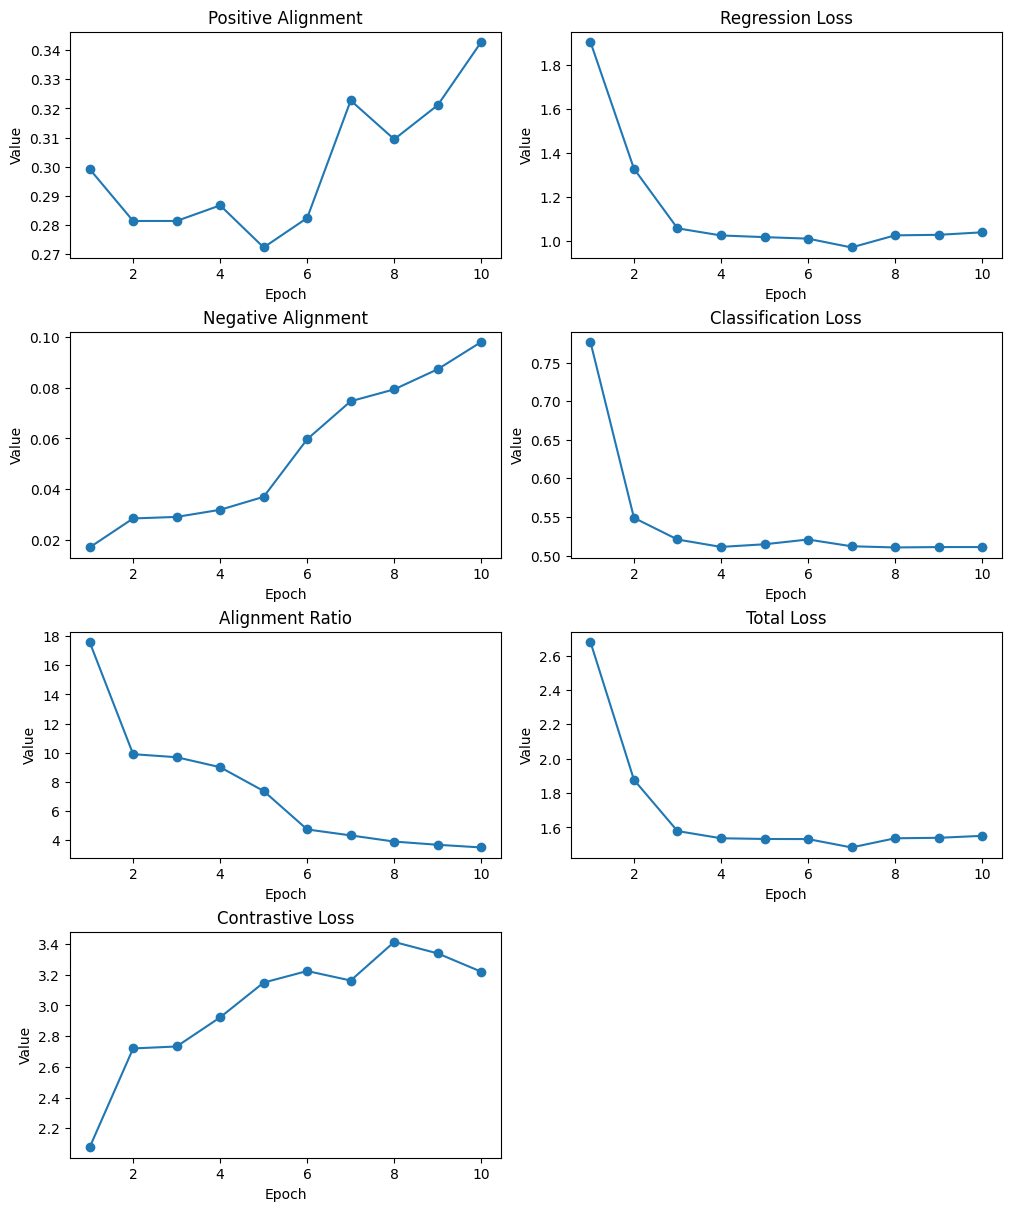

(GBMNet(
   (mme): MultiModalEncoder(
     (modality_net_map): ModuleDict(
       (hne): ModalityEncoder(
         (net): MLP(
           (network_layers): ModuleList(
             (0): Linear(in_features=1536, out_features=1024, bias=True)
             (1): Dropout(p=0.65, inplace=False)
             (2): SmoothingFunction()
             (3): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
             (4): Linear(in_features=1024, out_features=512, bias=True)
             (5): Dropout(p=0.65, inplace=False)
             (6): SmoothingFunction()
             (7): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
             (8): Linear(in_features=512, out_features=64, bias=True)
             (9): SmoothingFunction()
             (10): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
           )
         )
       )
       (scRNA): ModalityEncoder(
         (net): MLP(
           (network_layers): ModuleList(
             (0): Linear(in_features=3072, out_features=1024

In [33]:
predictive_training_loop(gbmnet, dataloader, 
                         EPOCHS_I=EPOCHS_I, 
                         base_lr_I=1e-4,
                         optimizer_I=Adam,
                         scheduler_I=torch.optim.lr_scheduler.CosineAnnealingLR,
                         scheduler_I_cfg=scheduler_I_cfg,
                         EPOCHS_II=EPOCHS_II,
                         base_lr_II=1e-4,
                         optimizer_II=Adam,
                         scheduler_II=torch.optim.lr_scheduler.CosineAnnealingLR,
                         scheduler_II_cfg=scheduler_II_cfg,
                         contrastive_loss_fn=RegularizedInfoNCELoss,
                         contrastive_loss_cfg=contrastive_loss_cfg,
                         reg_loss_fn=nn.MSELoss, # Classic Mean Squared Error Loss
                         clf_loss_fn=nn.BCEWithLogitsLoss, # Binary Cross Entropy with Sigmoid already applied, more stable
                         pretrained_mme=False, # If we are using a GBMNet with pretrained MME weights
                         freeze_mme=False, # If we modify the MME after Phase I or not.
                         eta_min_coef=0.01)

In [ ]:
# EPOCHS_I = 50
# EPOCHS_II = 50
# base_lr_I = 1e-4
# base_lr_II = 1e-4

# gbmnet = instantiate(gbmnet_cfg, GBMNet)

# optimizer_I = Adam(gbmnet.mme.parameters(), lr=base_lr_I)
# scheduler_I = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_I, T_max=EPOCHS_I, eta_min=0.01 * base_lr_I)

# optimizer_II = Adam(gbmnet.parameters(), lr=base_lr_II)
# scheduler_II = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_II, T_max=EPOCHS_II, eta_min=0.01 * base_lr_II)

# mse_loss_fn = nn.MSELoss()

# binary_act_fn = nn.Sigmoid()
# binary_loss_fn = nn.BCELoss()
# contrastive_loss_fn = RegularizedInfoNCELoss(list(name_emb_dict.keys()),
#                                      patient_map, 
#                                      temperature=0.05, 
#                                      similarity='nt-xent', 
#                                      use_all_positives=False,
#                                      alpha=0.1,
#                                      bound=-50,
#                                      slope=0.1,
#                                      rate=-5)

In [ ]:
# EPOCH_I_LOSSES = []
# for epoch in range(EPOCHS_I):
#     epoch_loss = []
    
#     for idx, batch in enumerate(dataloader):
#         # Get batch
#         patient_ids, modalities, X_dict, avail_mods, batch_targets, targets_names = batch
#         # print(batch_targets.size())
#         # Forward pass
#         contrastive_outputs, _ = gbmnet(X_dict)
#         # print(predictive_outputs.size())
#         contrastive_loss_batch = (contrastive_outputs, patient_ids, avail_mods)

#         # Loss computation (here me do contrastive and predictive at the same time)
#         contrastive_loss = contrastive_loss_fn(contrastive_loss_batch)
    
#         loss = contrastive_loss

#         # Backward pass
#         loss.backward()
#         optimizer_I.step()

#         # Learning schedule
#         before_lr_I = optimizer_I.param_groups[0]["lr"]
#         scheduler_I.step()

#         # Store losses
#         epoch_loss.append(loss.item())

#     print(f"\n\nLearning Rate: {before_lr_I}")
#     # For monitoring, not actually necessary
#     pos_align = np.mean(contrastive_loss_fn.infonce.pos_alignments)
#     neg_align = np.mean(contrastive_loss_fn.infonce.neg_alignments)
#     print("************************************************ GLOBAL ***********************************************")
#     print(f"Epoch {epoch} total loss: {np.mean(epoch_loss):.4f}".upper())
#     print("*******************************************************************************************************")

#     print("************************************************ EMBEDDING QUALITY ***********************************************")
#     print(f"\nEpoch {epoch} Embedding quality (Alignement): {pos_align:.4f}".upper())
#     print(f"Epoch {epoch} Embedding quality (Negative Alignement): {neg_align:.4f}".upper())
#     print(f"Epoch {epoch} Embedding quality (Alignement ratio): {np.abs(pos_align/(neg_align + 1e-8)):.4f}".upper())
#     print("*******************************************************************************************************")
#     contrastive_loss_fn.infonce.clear_alignments()
#     EPOCH_I_LOSSES.append(np.mean(epoch_loss))

In [ ]:
# EPOCH_II_LOSSES = []
# for epoch in range(EPOCHS_II):
#     epoch_loss = []
#     reg_loss_list = []
#     clf_loss_list = []
    
#     for idx, batch in enumerate(dataloader):
#         # Get batch
#         patient_ids, modalities, X_dict, avail_mods, batch_targets, targets_names = batch
#         # print(batch_targets.size())
#         # Forward pass
#         contrastive_outputs, predictive_outputs = gbmnet(X_dict)

#         # Here we compute the contrastive loss only to monitor how embedding quality is affected: 
#         # HERE GRADIENTS ARE NOT COMPUTED WITH RESPECT TO THE CONTRASTIVE LOSS !
#         contrastive_loss_batch = (contrastive_outputs, patient_ids, avail_mods)
#         contrastive_loss = contrastive_loss_fn(contrastive_loss_batch)
        
#         # Loss computation (here me do contrastive and predictive at the same time)
#         mse_loss = mse_loss_fn(predictive_outputs[:,:-2], batch_targets[:,:-2])
#         binary_loss = binary_loss_fn(binary_act_fn(predictive_outputs[:,-2:]), batch_targets[:,-2:])
    
#         loss = mse_loss + binary_loss #No contrastive loss

#         # Backward pass
#         loss.backward()
#         optimizer_II.step()

#         # Learning schedule
#         before_lr_II = optimizer_II.param_groups[0]["lr"]
#         scheduler_II.step()

#         # Store losses
#         epoch_loss.append(loss.item())
#         reg_loss_list.append(mse_loss.item())
#         clf_loss_list.append(binary_loss.item())

#     print(f"\n\nLearning Rate: {before_lr_II}")
#     # For monitoring, not actually necessary
#     pos_align = np.mean(contrastive_loss_fn.infonce.pos_alignments)
#     neg_align = np.mean(contrastive_loss_fn.infonce.neg_alignments)
#     print("************************************************ PREDICTIVE LOSS ***********************************************")
#     print(f"Epoch {epoch} total loss: {np.mean(epoch_loss):.4f}".upper())
#     print(f"Epoch {epoch} MSE loss: {np.mean(reg_loss_list):.4f}".upper())
#     print(f"Epoch {epoch} BCE loss: {np.mean(clf_loss_list):.4f}".upper())
#     print("*******************************************************************************************************")

#     print("************************************************ EMBEDDING QUALITY ***********************************************")
#     print(f"\nEpoch {epoch} Embedding quality (Alignement): {pos_align:.4f}".upper())
#     print(f"Epoch {epoch} Embedding quality (Negative Alignement): {neg_align:.4f}".upper())
#     print(f"Epoch {epoch} Embedding quality (Alignement ratio): {np.abs(pos_align/(neg_align + 1e-8)):.4f}".upper())
#     print("*******************************************************************************************************")
#     contrastive_loss_fn.infonce.clear_alignments()
#     EPOCH_II_LOSSES.append(np.mean(epoch_loss))

# There are nans popping up, we need to smooth gradient or clip them